In [1]:
import numpy as np
import glob
import os

import matplotlib.pyplot as plt

from scripts_fermions.operators import Hamiltonian, Boost
import yastn
from yastn.tn import mps

In [2]:
Nas = [(256, 0.125), (512, 0.0625), (512, 0.125)]
dEs = [-644.4618759299467 + 645.0617359295529, 2598.7026385786935 - 2598.116330318743, 1291.555420267803 - 1290.961527431732]
E_gs = dict(zip(Nas, [-645.0617359295529, -2598.702638578693, -1291.555420267803]))
g = 1
m = 0.0
sg2 = 0.25
x0 = 1.5

In [ ]:
probs_gs = {(N, a): np.load(f"./overlaps/probs_gs_gauss_{m=}_{N=}_{a=}.npy", allow_pickle=True).item() for N, a in Nas}
# probs_gs[N, a] is a dictionary with keys (t, PP, D)  = (time, P of Gaussian, MPS bond dimension)

probs_R = {(N, a): np.load(f"./overlaps/probs_gauss_R_{m=}_{N=}_{a=}.npy", allow_pickle=True).item() for N, a in Nas}
# probs_gs[N, a] is a dictionary with keys (t, PP, D, P)  = (time, P of Gaussian, MPS bond dimension, P of excited state)


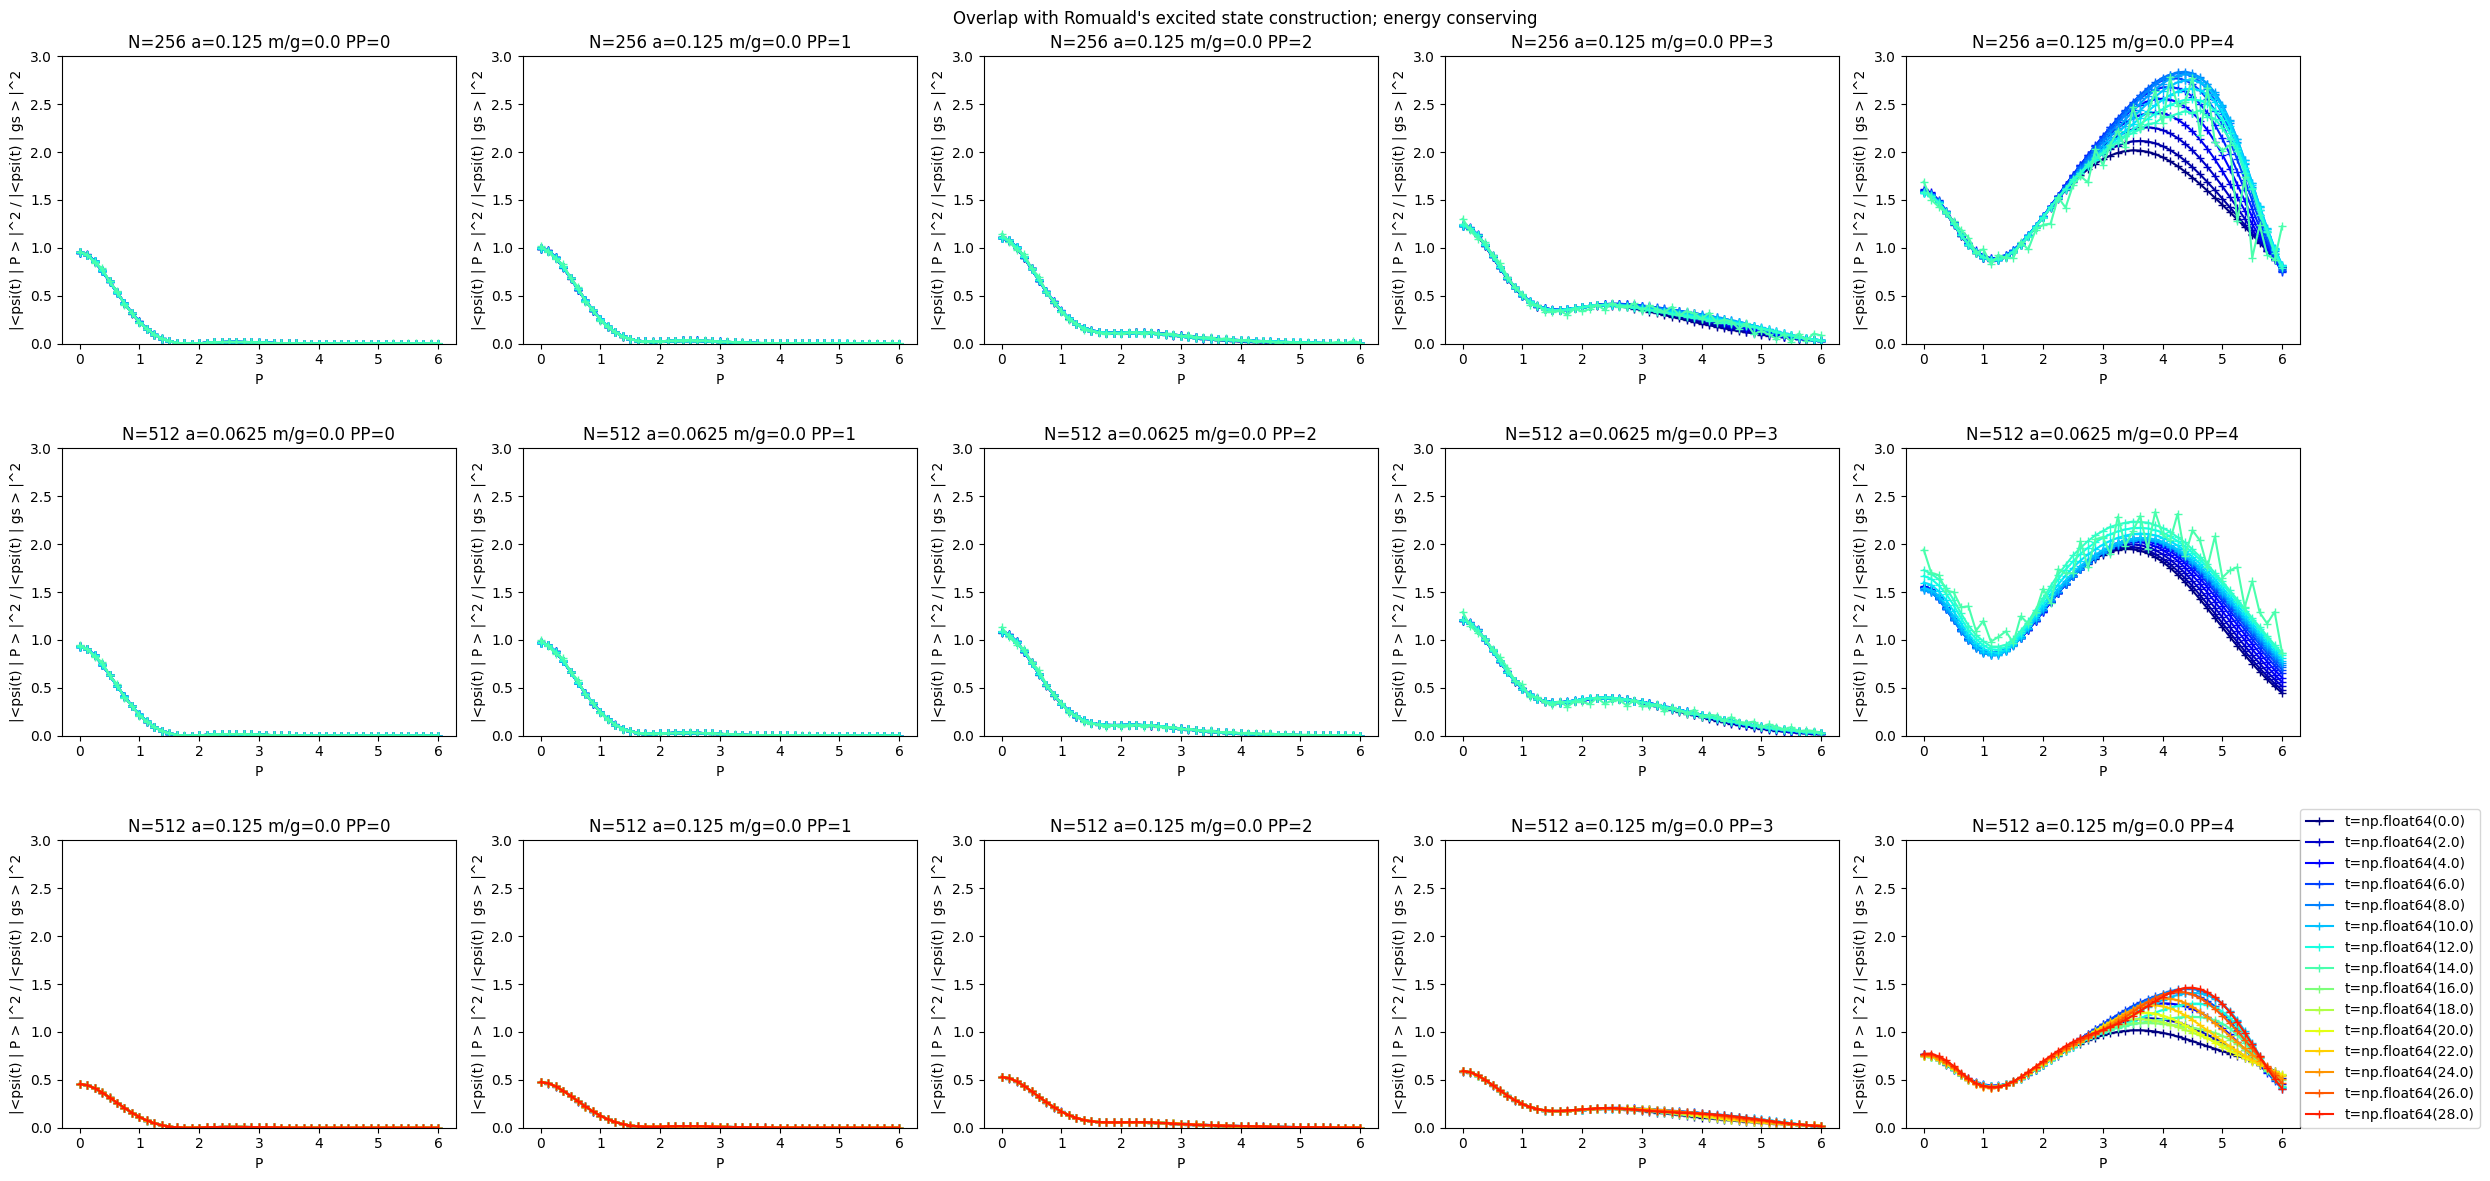

In [4]:
cm = plt.cm.jet
Ps = [0, 1, 2, 3, 4]

PPs = np.linspace(0, 6, 49)

fig, axs = plt.subplots(len(Nas), len(Ps), squeeze=False)
fig.set_size_inches( len(Ps) * 5, len(Nas) * 4)
for ii, ((N, a), dE) in enumerate(zip(Nas, dEs)):
  #
  ts = sorted(set(t for t, PP, D, P in probs_R[N, a]))
  Ds = sorted(set(D for t, PP, D, P in probs_R[N, a]))
  Ds = [ 512]
  #
  for jj, PP in enumerate(Ps):
      for D in Ds:
        for t in ts[:-2]:
          pr = [probs_R[N, a][t, PP, D, P] / probs_gs[N, a][t, PP, D] for P in PPs]
          sym = '-+' if D == Ds[0] else '-o'
          line, = axs[ii, jj].plot(PPs, pr, sym, color = cm(t / 32))
          if D == Ds[0]:
            line.set_label(f"{t=}")
      axs[ii,jj].set_xlabel('P')
      axs[ii,jj].set_ylabel("|<psi(t) | P > |^2 / |<psi(t) | gs > |^2")
      #axs[ii,jj].set_xlim([0, 2])
      axs[ii,jj].set_title(f"{N=} {a=} {m/g=} {PP=}")
      axs[ii,jj].set_ylim([0, 3])

axs[-1, -1].legend(loc=(1, 0))
fig.suptitle("Overlap with Romuald's excited state construction; energy conserving")

plt.tight_layout()


In [5]:
E_t = {}
for N, a in Nas:
    fname = f"./overlaps/Eng_gauss_{m=}_{N=}_{a=}.npy"
    E_t[N,a] = np.load(fname, allow_pickle=True).item()

E_P = {}
for N, a in Nas:
    data = np.load(f"./results_fermions/construct_P_{m=}_{N=}_{a=}.npy", allow_pickle=True).item()
    E_P[N, a] = data['energy']

/home/marek/.conda/envs/yastn/lib/python3.12/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/marek/.conda/envs/yastn/lib/python3.12/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


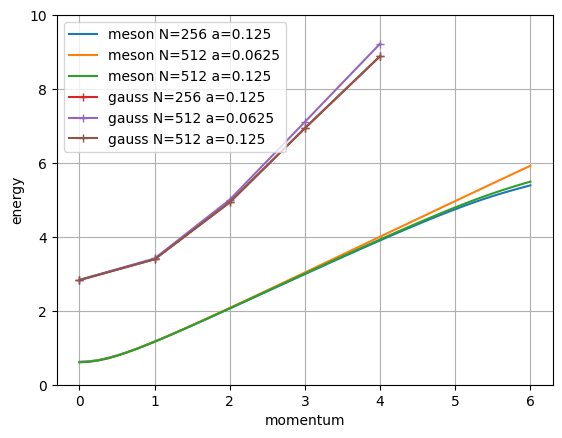

In [7]:
for N, a in Nas:
    k = np.array(list(E_P[N, a].keys()))
    v = np.array(list(E_P[N, a].values()))
    plt.plot(k, v - E_gs[N, a], '-', label=f"meson {N=} {a=}")
plt.ylim(0, 6)
plt.xlabel('momentum')
plt.ylabel('energy')


for N, a in Nas:
    dd = {k[1]: v for k, v in E_t[N, a].items()}
    k = np.array(list(dd.keys()))
    v = np.array(list(dd .values()))
    plt.plot(k, v - E_gs[N, a], '-+', label=f"gauss {N=} {a=}")
plt.ylim(0, 10)
plt.grid()

plt.legend()
